<a href="https://colab.research.google.com/github/meti-creator/AQI-Regression-Project/blob/main/twitter_customer_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd

# Load the dataset, using the 'python' engine to handle potential parsing errors
# and skipping bad lines.
df = pd.read_csv('/content/sample_data/twitter_training.csv', engine='python', on_bad_lines='skip')

# Display the first 5 rows of the DataFrame
display(df.head())

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [10]:
# Display the current column names
display(df.columns)

Index(['2401', 'Borderlands', 'Positive',
       'im getting on borderlands and i will murder you all ,'],
      dtype='object')

In [11]:
# Rename the columns for clarity
df.columns = ['ID', 'Game', 'Sentiment', 'Tweet_Text']

# Display the first 5 rows with the new column names
display(df.head())

,ID,Game,Sentiment,Tweet_Text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [12]:
# Check for missing values in the 'Tweet_Text' column
missing_tweet_text = df['Tweet_Text'].isnull().sum()
print(f"Number of missing values in 'Tweet_Text': {missing_tweet_text}")

# Also check for empty strings, which might be treated as non-null by isnull()
empty_tweet_text = (df['Tweet_Text'] == '').sum()
print(f"Number of empty strings in 'Tweet_Text': {empty_tweet_text}")

Number of missing values in 'Tweet_Text': 686
Number of empty strings in 'Tweet_Text': 0


In [13]:
df['Tweet_Text'] = df['Tweet_Text'].fillna('')

# Verify that there are no more missing values in 'Tweet_Text'
missing_tweet_text_after = df['Tweet_Text'].isnull().sum()
empty_tweet_text_after = (df['Tweet_Text'] == '').sum()

print(f"Number of missing values in 'Tweet_Text' after filling: {missing_tweet_text_after}")
print(f"Number of empty strings in 'Tweet_Text' after filling: {empty_tweet_text_after}")

Number of missing values in 'Tweet_Text' after filling: 0
Number of empty strings in 'Tweet_Text' after filling: 686


In [14]:
# Get unique values in the 'Sentiment' column
unique_sentiments = df['Sentiment'].unique()
display(unique_sentiments)

array(['Positive', 'Neutral', 'Negative', 'Irrelevant'], dtype=object)

In [15]:
# Convert 'Tweet_Text' to lowercase
df['Tweet_Text'] = df['Tweet_Text'].str.strip().str.lower()

# Display the first few rows to show the change
display(df.head())

,ID,Game,Sentiment,Tweet_Text
0,2401,Borderlands,Positive,i am coming to the borders and i will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [16]:
# Count the number of tweets for each sentiment category
sentiment_counts = df['Sentiment'].value_counts()
display(sentiment_counts)

,count
Sentiment,
Negative,22542
Positive,20831
Neutral,18318
Irrelevant,12990


In [17]:
import re

# Remove punctuation, numbers, and special characters
df['Tweet_Text'] = df['Tweet_Text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

# Remove extra spaces
df['Tweet_Text'] = df['Tweet_Text'].apply(lambda x: re.sub(r'\s+', ' ', x)).str.strip()

# Display the first few rows to show the change
display(df.head())

,ID,Game,Sentiment,Tweet_Text
0,2401,Borderlands,Positive,i am coming to the borders and i will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you all
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [18]:
import nltk
from nltk.corpus import stopwords

# Download the stopwords corpus if you haven't already
nltk.download('stopwords')

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

# Function to remove stopwords
def remove_stopwords(text):
    return ' '.join([word for word in str(text).split() if word not in stop_words])

# Apply the function to the 'Tweet_Text' column
df['Tweet_Text'] = df['Tweet_Text'].apply(remove_stopwords)

# Display the first few rows to show the change
display(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,ID,Game,Sentiment,Tweet_Text
0,2401,Borderlands,Positive,coming borders kill
1,2401,Borderlands,Positive,im getting borderlands kill
2,2401,Borderlands,Positive,im coming borderlands murder
3,2401,Borderlands,Positive,im getting borderlands murder
4,2401,Borderlands,Positive,im getting borderlands murder


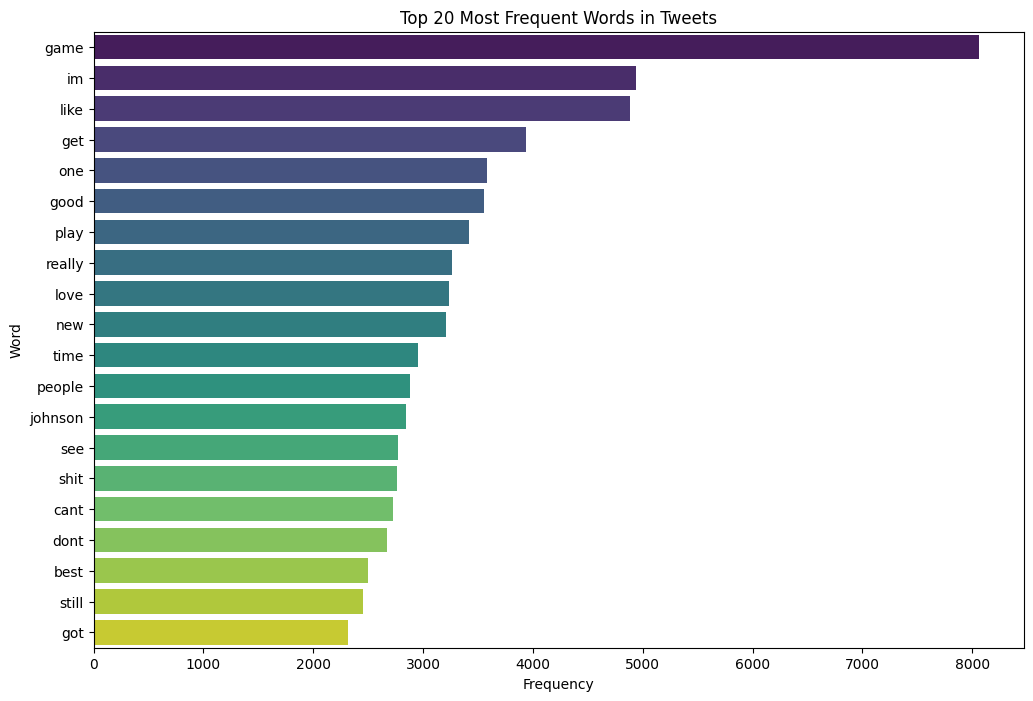

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Combine all tweet texts into a single string and split into words
all_words = ' '.join(df['Tweet_Text']).split()

# Count word frequencies
word_freq = Counter(all_words)

# Get the 20 most common words
most_common_words = word_freq.most_common(20)

# Convert to DataFrame for easier plotting with seaborn
most_common_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])

# Create the bar plot, addressing the FutureWarning by explicitly setting hue and legend
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', hue='Word', data=most_common_df, palette='viridis', legend=False)
plt.title('Top 20 Most Frequent Words in Tweets')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

In [20]:
from collections import Counter
import pandas as pd

sentiments = df['Sentiment'].unique()

# Dictionary to store most common words for each sentiment
sentiment_word_frequencies = {}

for sentiment in sentiments:
    # Filter DataFrame for the current sentiment
    sentiment_df = df[df['Sentiment'] == sentiment]

    # Combine all tweet texts for this sentiment
    all_words_sentiment = ' '.join(sentiment_df['Tweet_Text']).split()

    # Count word frequencies
    word_freq_sentiment = Counter(all_words_sentiment)

    # Get the 10 most common words
    most_common_10 = word_freq_sentiment.most_common(10)

    sentiment_word_frequencies[sentiment] = most_common_10

# Display the top 10 words for each sentiment
for sentiment, words in sentiment_word_frequencies.items():
    print(f"\n--- Top 10 words for {sentiment} sentiment ---")
    # Convert to DataFrame for better display
    display(pd.DataFrame(words, columns=['Word', 'Frequency']))


--- Top 10 words for Positive sentiment ---


,Word,Frequency
0,game,2274
1,love,1777
2,im,1769
3,good,1616
4,like,1359
5,really,1290
6,new,1199
7,best,1112
8,one,1058
9,play,1047



--- Top 10 words for Neutral sentiment ---


,Word,Frequency
0,johnson,1772
1,game,1230
2,amazon,1122
3,like,909
4,im,891
5,get,886
6,one,857
7,new,850
8,facebook,839
9,google,832



--- Top 10 words for Negative sentiment ---


,Word,Frequency
0,game,3768
1,get,1662
2,like,1620
3,shit,1516
4,im,1425
5,fix,1313
6,fuck,1259
7,cant,1229
8,play,1209
9,dont,1127



--- Top 10 words for Irrelevant sentiment ---


,Word,Frequency
0,like,994
1,see,943
2,player,882
3,im,856
4,game,794
5,people,764
6,ban,739
7,love,670
8,one,663
9,good,663


In [21]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'Sentiment' column
df['Sentiment_Encoded'] = label_encoder.fit_transform(df['Sentiment'])

# Display the mapping of original sentiments to encoded labels
sentiment_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Sentiment to Encoded Label Mapping:", sentiment_mapping)

# Display the first few rows with the new encoded column
display(df.head())

Sentiment to Encoded Label Mapping: {'Irrelevant': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}


,ID,Game,Sentiment,Tweet_Text,Sentiment_Encoded
0,2401,Borderlands,Positive,coming borders kill,3
1,2401,Borderlands,Positive,im getting borderlands kill,3
2,2401,Borderlands,Positive,im coming borderlands murder,3
3,2401,Borderlands,Positive,im getting borderlands murder,3
4,2401,Borderlands,Positive,im getting borderlands murder,3


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Define features (X) and target (y)
X = df['Tweet_Text']
y = df['Sentiment_Encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting to 5000 features to manage dimensionality

# Fit and transform the training data, then transform the test data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF transformed training data shape: {X_train_tfidf.shape}")
print(f"TF-IDF transformed testing data shape: {X_test_tfidf.shape}")

Training set size: 59744 samples
Testing set size: 14937 samples
TF-IDF transformed training data shape: (59744, 5000)
TF-IDF transformed testing data shape: (14937, 5000)


In [25]:
from sklearn.metrics import classification_report, accuracy_score

# Predict on the test set
y_pred = logistic_model.predict(X_test_tfidf)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Accuracy: 0.6812

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.70      0.53      0.60      2598
    Negative       0.73      0.76      0.75      4509
     Neutral       0.60      0.66      0.63      3664
    Positive       0.69      0.71      0.70      4166

    accuracy                           0.68     14937
   macro avg       0.68      0.66      0.67     14937
weighted avg       0.68      0.68      0.68     14937



In [24]:
from sklearn.linear_model import LogisticRegression

# Initialize and train a Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_tfidf, y_train)


print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [26]:
import re # Import the regular expression module

# Define a function to preprocess a single tweet
def preprocess_tweet(tweet):
    # Convert to lowercase
    tweet = tweet.strip().lower()
    # Remove punctuation, numbers, and special characters
    tweet = re.sub(r'[^a-z\s]', '', tweet)
    # Remove extra spaces
    tweet = re.sub(r'\s+', ' ', tweet).strip()
    # Remove stopwords
    tweet = ' '.join([word for word in tweet.split() if word not in stop_words])
    return tweet

# Example new tweet for prediction (you can change this!)
new_tweet = "This game is absolutely fantastic and I love playing it!"

# Preprocess the new tweet
preprocessed_new_tweet = preprocess_tweet(new_tweet)

print(f"Original Tweet: {new_tweet}")
print(f"Preprocessed Tweet: {preprocessed_new_tweet}")

Original Tweet: This game is absolutely fantastic and I love playing it!
Preprocessed Tweet: game absolutely fantastic love playing


In [27]:
# Vectorize the preprocessed new tweet using the trained TF-IDF vectorizer
# We need to pass it as a list because TfidfVectorizer expects an iterable of documents
new_tweet_tfidf = tfidf_vectorizer.transform([preprocessed_new_tweet])

print(f"TF-IDF transformed shape for new tweet: {new_tweet_tfidf.shape}")

TF-IDF transformed shape for new tweet: (1, 5000)


In [28]:
# Predict the sentiment using the trained Logistic Regression model
predicted_sentiment_encoded = logistic_model.predict(new_tweet_tfidf)

# Convert the encoded sentiment back to its original label
predicted_sentiment_label = label_encoder.inverse_transform(predicted_sentiment_encoded)

print(f"Predicted Sentiment: {predicted_sentiment_label[0]}")

Predicted Sentiment: Positive
